<a href="https://colab.research.google.com/github/GraceGrider272/BAE305-SP25-Lab-9/blob/main/BAE305_Lab_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

try:
    station_df = pd.read_csv('/content/station.csv')
    print("Successfully loaded 'station.csv' into a DataFrame.")
    print("First 5 rows of the DataFrame:")
    display(station_df.head())
except FileNotFoundError:
    print("Error: 'station.csv' not found. Please ensure the file is in the correct path.")
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")

Successfully loaded 'station.csv' into a DataFrame.
First 5 rows of the DataFrame:


,OrganizationIdentifier,OrganizationFormalName,MonitoringLocationIdentifier,MonitoringLocationName,MonitoringLocationTypeName,MonitoringLocationDescriptionText,HUCEightDigitCode,DrainageAreaMeasure/MeasureValue,DrainageAreaMeasure/MeasureUnitCode,ContributingDrainageAreaMeasure/MeasureValue,...,AquiferName,LocalAqfrName,FormationTypeText,AquiferTypeName,ConstructionDateText,WellDepthMeasure/MeasureValue,WellDepthMeasure/MeasureUnitCode,WellHoleDepthMeasure/MeasureValue,WellHoleDepthMeasure/MeasureUnitCode,ProviderName
0,USGS-KY,USGS Kentucky Water Science Center,USGS-03254520,"LICKING RIVER AT HWY 536 NEAR ALEXANDRIA, KY",Stream,NaN,5100101,3593.0,sq mi,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NWIS
1,USGS-KY,USGS Kentucky Water Science Center,USGS-03290500,"KENTUCKY RIVER AT LOCK 2 AT LOCKPORT, KY",Stream,NaN,5100205,6180.0,sq mi,5984.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NWIS
2,USGS-KY,USGS Kentucky Water Science Center,USGS-03302058,"Salt River at Main Range Rd nr West Point, KY",Stream,NaN,5140102,2790.0,sq mi,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NWIS
3,11NPSWRD_WQX,National Park Service Water Resources Division,11NPSWRD_WQX-ABLI_HSSS,Howell Spring,Spring,Howell Spring is located just outside the park...,5110001,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
4,11NPSWRD_WQX,National Park Service Water Resources Division,11NPSWRD_WQX-ABLI_KCKC,Knob Creek,River/Stream,"The park's new lands cross US31E, and for a sh...",5140103,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET


In [ ]:
import folium
import pandas as pd

# Ensure station_df exists and has 'LatitudeMeasure' and 'LongitudeMeasure' columns
if 'station_df' in locals() and not station_df.empty and 'LatitudeMeasure' in station_df.columns and 'LongitudeMeasure' in station_df.columns:
    # Filter out rows with NaN LatitudeMeasure or LongitudeMeasure to avoid errors
    valid_stations = station_df.dropna(subset=['LatitudeMeasure', 'LongitudeMeasure'])

    if not valid_stations.empty:
        # Calculate the center of the map based on the average location of valid stations
        center_lat = valid_stations['LatitudeMeasure'].mean()
        center_lon = valid_stations['LongitudeMeasure'].mean()

        # Create a Folium map centered around the average location
        station_map = folium.Map(location=[center_lat, center_lon], zoom_start=10)

        # Add a marker for each station
        for index, row in valid_stations.iterrows():
            # Create popup text with station name and ID if available
            popup_text = f"<b>Station:</b> {row.get('name', 'N/A')}<br><b>ID:</b> {row.get('station_id', 'N/A')}"
            folium.Marker(
                location=[row['LatitudeMeasure'], row['LongitudeMeasure']],
                popup=popup_text,
                tooltip=row.get('name', 'Station') # Tooltip appears on hover
            ).add_to(station_map)

        # Display the map
        print("Interactive map of station locations:")
        display(station_map)
    else:
        print("No valid station locations found after dropping rows with missing LatitudeMeasure or LongitudeMeasure.")
else:
    print("Error: 'station_df' is not available, is empty, or does not contain 'LatitudeMeasure' and 'LongitudeMeasure' columns. Please ensure the 'station.csv' file was loaded correctly.")

Interactive map of station locations:


In [ ]:
import pandas as pd

try:
    narrow_df = pd.read_csv('/content/narrowresult.csv')
    print("Successfully loaded 'narrowresult.csv' into a DataFrame.")
    print("First 5 rows of the DataFrame:")
    display(narrow_df.head())
except FileNotFoundError:
    print("Error: 'narrowresult.csv' not found. Please ensure the file is in the correct path.")
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")

Successfully loaded 'narrowresult.csv' into a DataFrame.
First 5 rows of the DataFrame:


,OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,MonitoringLocationIdentifier,ResultIdentifier,DataLoggerLine,ResultDetectionConditionText,...,AnalysisEndTime/TimeZoneCode,ResultLaboratoryCommentCode,ResultLaboratoryCommentText,ResultDetectionQuantitationLimitUrl,LaboratoryAccreditationIndicator,LaboratoryAccreditationAuthorityName,TaxonomistAccreditationIndicator,TaxonomistAccreditationAuthorityName,LabSamplePreparationUrl,ProviderName
0,31ORWUNT_WQX,Ohio River Valley Water Sanitation Commission ...,31ORWUNT_WQX-OR640M:20240521:1030:SFST,2024-05-21,10:30:00,EDT,31ORWUNT_WQX-OR640M,STORET-1046729626,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
1,31ORWUNT_WQX,Ohio River Valley Water Sanitation Commission ...,31ORWUNT_WQX-OR4495M:20240523:1330:SFST,2024-05-23,13:30:00,EDT,31ORWUNT_WQX-OR4495M,STORET-1046729053,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
2,31ORWUNT_WQX,Ohio River Valley Water Sanitation Commission ...,31ORWUNT_WQX-SA0.8M:20240501:1215:FM,2024-05-01,12:15:00,EDT,31ORWUNT_WQX-SA0.8M,STORET-1046628028,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
3,31ORWUNT_WQX,Ohio River Valley Water Sanitation Commission ...,31ORWUNT_WQX-OR4495M:20240523:1330:SRR,2024-05-23,13:30:00,EDT,31ORWUNT_WQX-OR4495M,STORET-1046729082,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
4,31ORWUNT_WQX,Ohio River Valley Water Sanitation Commission ...,31ORWUNT_WQX-IN604BHAB:OH-MLD531.5:20240625:11...,2024-06-25,11:45:00,EST,31ORWUNT_WQX-OH-MLD531.5,STORET-1047027510,NaN,Not Detected,...,NaN,NaN,NaN,https://www.waterqualitydata.us/data/providers...,NaN,NaN,NaN,NaN,NaN,STORET


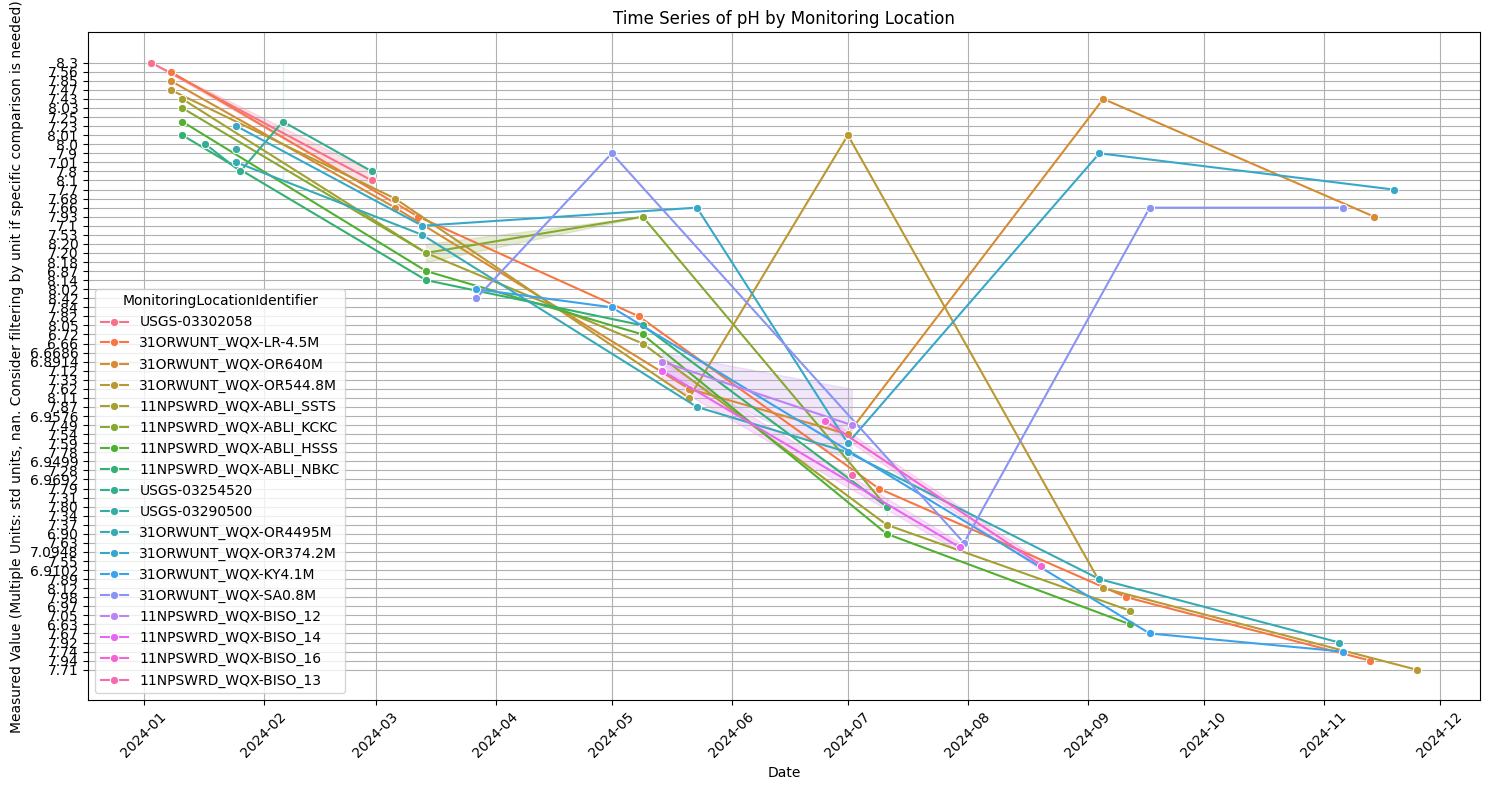

In [ ]:
plot_water_quality_time_series(narrow_df, 'pH')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_water_quality_time_series(df, characteristic_name):
    """
    Filters water quality data for a specific characteristic and plots the time series
    for each monitoring location.

    Args:
        df (pd.DataFrame): The input DataFrame containing water quality data.
        characteristic_name (str): The name of the water quality characteristic to filter by.

    Returns:
        None: Displays a matplotlib plot.
    """
    # Ensure 'ActivityStartDate' is datetime
    df['ActivityStartDate'] = pd.to_datetime(df['ActivityStartDate'])

    # Filter for the desired characteristic (CharacteristicName column)
    filtered_df = df[df['CharacteristicName'] == characteristic_name].copy()

    if filtered_df.empty:
        print(f"No data found for characteristic: '{characteristic_name}'")
        return

    # Sort by date for proper time series plotting
    filtered_df = filtered_df.sort_values(by='ActivityStartDate')

    plt.figure(figsize=(15, 8))
    sns.lineplot(
        data=filtered_df,
        x='ActivityStartDate',
        y='ResultMeasureValue', # Plotting ResultMeasureValue
        hue='MonitoringLocationIdentifier',
        marker='o', # Add markers for individual data points
        dashes=False, # Ensure solid lines
        legend='full'
    )

    # Get the unique unit of measure for the characteristic, if available
    unique_units = filtered_df['ResultMeasure/MeasureUnitCode'].unique()
    y_axis_label = 'Measured Value'
    if len(unique_units) == 1:
        y_axis_label = f"Measured Value ({unique_units[0]})"
    elif len(unique_units) > 1:
        # Convert all units to string before joining to avoid TypeError
        y_axis_label = f"Measured Value (Multiple Units: {', '.join(map(str, unique_units))}. Consider filtering by unit if specific comparison is needed)"


    plt.title(f'Time Series of {characteristic_name} by Monitoring Location')
    plt.xlabel('Date')
    plt.ylabel(y_axis_label)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print("The function 'plot_water_quality_time_series' has been defined.")
print("You can now call it with your DataFrame and a characteristic name, e.g.:")
print("plot_water_quality_time_series(narrow_df, 'pH')")

The function 'plot_water_quality_time_series' has been defined.
You can now call it with your DataFrame and a characteristic name, e.g.:
plot_water_quality_time_series(narrow_df, 'pH')


In [ ]:
if 'narrow_df' in locals() and not narrow_df.empty and 'CharacteristicName' in narrow_df.columns:
    unique_characteristics = narrow_df['CharacteristicName'].unique()
    print("Unique Characteristic Names:")
    for char_name in unique_characteristics:
        print(f"- {char_name}")
else:
    print("Error: 'narrow_df' is not available, is empty, or does not contain a 'CharacteristicName' column.")

Unique Characteristic Names:
- Barium
- Nickel
- pH
- Magnesium
- Orthophosphate
- Escherichia coli
- Gran acid neutralizing capacity
- Iron
- Beryllium
- Antimony
- Turbidity
- Organic carbon
- Thallium
- Mercury
- Cadmium
- Dissolved oxygen (DO)
- Copper
- Specific conductance
- Nitrate
- Kjeldahl nitrogen
- Total suspended solids
- Potassium
- Zinc
- Sulfate
- Aluminum
- Bromide
- Temperature, air
- Temperature, water
- Flow, stream stage (choice list)
- Fixed suspended solids
- Selenium
- Chromium
- Biochemical oxygen demand, standard conditions
- Total Nitrogen, mixed forms
- Lead
- Strontium
- Sodium
- Nitrate + Nitrite
- Hardness, Ca, Mg
- Volatile suspended solids
- Arsenic
- Manganese
- Total dissolved solids
- Phenols
- Ammonia
- Nitrite
- Phosphorus
- Silver
- Precipitation
- Ammonium
- Hardness, carbonate
- Total Coliform
- Stream stage
- General observation (text)
- Flow
- Calcium
- Hydrogen phosphate
- Chloride
- Dissolved oxygen saturation
- Weather condition (WMO code 4

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_two_characteristics_time_series(df, characteristic_name1, characteristic_name2):
    """
    Filters water quality data for two specific characteristics and plots their time series
    for each monitoring location on the same graph.

    Args:
        df (pd.DataFrame): The input DataFrame containing water quality data.
        characteristic_name1 (str): The name of the first water quality characteristic to plot.
        characteristic_name2 (str): The name of the second water quality characteristic to plot.

    Returns:
        None: Displays a matplotlib plot.
    """
    # Ensure 'ActivityStartDate' is datetime
    df['ActivityStartDate'] = pd.to_datetime(df['ActivityStartDate'])

    # Filter for the desired characteristics
    filtered_df = df[df['CharacteristicName'].isin([characteristic_name1, characteristic_name2])].copy()

    if filtered_df.empty:
        print(f"No data found for characteristics: '{characteristic_name1}' and '{characteristic_name2}'")
        return

    # Sort by date for proper time series plotting
    filtered_df = filtered_df.sort_values(by='ActivityStartDate')

    plt.figure(figsize=(15, 8))
    sns.lineplot(
        data=filtered_df,
        x='ActivityStartDate',
        y='ResultMeasureValue',
        hue='CharacteristicName', # Differentiate between the two characteristics
        style='MonitoringLocationIdentifier', # Differentiate monitoring locations
        marker='o',
        dashes=False,
        legend='full'
    )

    # Get unique units for each characteristic
    units1 = filtered_df[filtered_df['CharacteristicName'] == characteristic_name1]['ResultMeasure/MeasureUnitCode'].unique()
    units2 = filtered_df[filtered_df['CharacteristicName'] == characteristic_name2]['ResultMeasure/MeasureUnitCode'].unique()

    y_axis_label = 'Measured Value'
    if len(units1) == 1 and len(units2) == 1 and units1[0] == units2[0]:
        y_axis_label = f"Measured Value ({units1[0]})"
    elif len(units1) > 0 and len(units2) > 0:
        y_axis_label = f"Measured Value (Units: {', '.join(map(str, units1))} for {characteristic_name1}; {', '.join(map(str, units2))} for {characteristic_name2}. Be aware of potential different units.)"
    elif len(units1) > 0:
        y_axis_label = f"Measured Value (Units: {', '.join(map(str, units1))} for {characteristic_name1})"
    elif len(units2) > 0:
        y_axis_label = f"Measured Value (Units: {', '.join(map(str, units2))} for {characteristic_name2})"


    plt.title(f'Time Series of {characteristic_name1} and {characteristic_name2} by Monitoring Location')
    plt.xlabel('Date')
    plt.ylabel(y_axis_label)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print("The function 'plot_two_characteristics_time_series' has been defined.")
print("You can now call it with your DataFrame and two characteristic names, e.g.:")
print("plot_two_characteristics_time_series(narrow_df, 'pH', 'Temperature, water')")

The function 'plot_two_characteristics_time_series' has been defined.
You can now call it with your DataFrame and two characteristic names, e.g.:
plot_two_characteristics_time_series(narrow_df, 'pH', 'Temperature, water')


Now that the `plot_two_characteristics_time_series` function is defined, you can use it to compare any two characteristics. For example, let's compare 'pH' and 'Dissolved oxygen (DO)':

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_two_characteristics_dual_axis_time_series(df, characteristic_name1, characteristic_name2):
    """
    Filters water quality data for two specific characteristics and plots their time series
    for each monitoring location, using a dual Y-axis for different scales.

    Args:
        df (pd.DataFrame): The input DataFrame containing water quality data.
        characteristic_name1 (str): The name of the first water quality characteristic (left y-axis).
        characteristic_name2 (str): The name of the second water quality characteristic (right y-axis).

    Returns:
        None: Displays a matplotlib plot.
    """
    # Ensure 'ActivityStartDate' is datetime
    df['ActivityStartDate'] = pd.to_datetime(df['ActivityStartDate'])

    # Filter data for each characteristic
    df1 = df[df['CharacteristicName'] == characteristic_name1].copy()
    df2 = df[df['CharacteristicName'] == characteristic_name2].copy()

    # Convert 'ResultMeasureValue' to numeric, coercing errors, then drop NaNs for plotting
    df1['ResultMeasureValue'] = pd.to_numeric(df1['ResultMeasureValue'], errors='coerce')
    df2['ResultMeasureValue'] = pd.to_numeric(df2['ResultMeasureValue'], errors='coerce')

    df1.dropna(subset=['ResultMeasureValue'], inplace=True)
    df2.dropna(subset=['ResultMeasureValue'], inplace=True)

    if df1.empty and df2.empty:
        print(f"No valid numeric data found for either characteristic: '{characteristic_name1}' or '{characteristic_name2}' after coercing to numeric and dropping NaNs.")
        return
    if df1.empty:
        print(f"No valid numeric data found for '{characteristic_name1}'. Plotting only '{characteristic_name2}' on the right axis.")
    if df2.empty:
        print(f"No valid numeric data found for '{characteristic_name2}'. Plotting only '{characteristic_name1}' on the left axis.")

    fig, ax1 = plt.subplots(figsize=(15, 8))

    # Convert MonitoringLocationIdentifier to string type to prevent TypeError in plotting
    df1['MonitoringLocationIdentifier'] = df1['MonitoringLocationIdentifier'].astype(str)
    df2['MonitoringLocationIdentifier'] = df2['MonitoringLocationIdentifier'].astype(str)

    # Plot characteristic 1 on left y-axis (ax1)
    color1 = 'tab:blue'
    ax1.set_xlabel('Date')
    ax1.set_ylabel(f'{characteristic_name1} Value', color=color1)
    if not df1.empty:
        # Group by MonitoringLocationIdentifier to ensure separate lines if desired
        for location in df1['MonitoringLocationIdentifier'].unique():
            location_df = df1[df1['MonitoringLocationIdentifier'] == location].sort_values(by='ActivityStartDate')
            ax1.plot(location_df['ActivityStartDate'], location_df['ResultMeasureValue'],
                     marker='o', linestyle='-', color=color1, label=f'{characteristic_name1} ({location})')
    ax1.tick_params(axis='y', labelcolor=color1)

    # Get unique units for characteristic 1
    unique_units1 = df1['ResultMeasure/MeasureUnitCode'].unique()
    if len(unique_units1) == 1: # Only one unit, use it
        ax1.set_ylabel(f'{characteristic_name1} ({unique_units1[0]})', color=color1)
    elif len(unique_units1) > 1: # Multiple units, list them
        # Convert all units to string before joining to avoid TypeError
        ax1.set_ylabel(f'{characteristic_name1} (Multiple Units: {', '.join(map(str, unique_units1))})', color=color1)

    # Create a second y-axis (ax2) for characteristic 2
    ax2 = ax1.twinx()
    color2 = 'tab:red'
    ax2.set_ylabel(f'{characteristic_name2} Value', color=color2)
    if not df2.empty:
        # Group by MonitoringLocationIdentifier to ensure separate lines if desired
        for location in df2['MonitoringLocationIdentifier'].unique():
            location_df = df2[df2['MonitoringLocationIdentifier'] == location].sort_values(by='ActivityStartDate')
            ax2.plot(location_df['ActivityStartDate'], location_df['ResultMeasureValue'],
                     marker='x', linestyle='--', color=color2, label=f'{characteristic_name2} ({location})')
    ax2.tick_params(axis='y', labelcolor=color2)

    # Get unique units for characteristic 2
    unique_units2 = df2['ResultMeasure/MeasureUnitCode'].unique()
    if len(unique_units2) == 1:
        ax2.set_ylabel(f'{characteristic_name2} ({unique_units2[0]})', color=color2)
    elif len(unique_units2) > 1:
        ax2.set_ylabel(f'{characteristic_name2} (Multiple Units: {', '.join(map(str, unique_units2))})', color=color2)


    plt.title(f'Time Series of {characteristic_name1} and {characteristic_name2} (Dual Axis)')
    plt.grid(True)
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.xticks(rotation=45)

    # Combine legends from both axes and place it outside the plot area
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small')

    plt.show()

print("The function 'plot_two_characteristics_dual_axis_time_series' has been defined.")
print("You can now call it with your DataFrame and two characteristic names, e.g.:")
print("plot_two_characteristics_dual_axis_time_series(narrow_df, 'pH', 'Temperature, water')")

The function 'plot_two_characteristics_dual_axis_time_series' has been defined.
You can now call it with your DataFrame and two characteristic names, e.g.:
plot_two_characteristics_dual_axis_time_series(narrow_df, 'pH', 'Temperature, water')


First, we need to install Streamlit. Since Streamlit apps are typically run as separate Python scripts, we'll save our app code to a `.py` file and then run it from the command line within Colab.

In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 82.2 MB/s eta 0:00:00


Now, let's create the Streamlit app code. We'll save it to a file named `water_quality_app.py`.

In [ ]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# To make the existing plot_water_quality_time_series function work within Streamlit,
# we need to ensure it doesn't call plt.show() directly but returns the figure.

# Re-define or modify plot_water_quality_time_series to return figure
def plot_water_quality_time_series_streamlit(df, characteristic_name):
    df['ActivityStartDate'] = pd.to_datetime(df['ActivityStartDate'])
    filtered_df = df[df['CharacteristicName'] == characteristic_name].copy()

    if filtered_df.empty:
        st.warning(f"No data found for characteristic: '{characteristic_name}'")
        return None

    filtered_df = filtered_df.sort_values(by='ActivityStartDate')

    fig, ax = plt.subplots(figsize=(15, 8))
    sns.lineplot(
        data=filtered_df,
        x='ActivityStartDate',
        y='ResultMeasureValue',
        hue='MonitoringLocationIdentifier',
        marker='o',
        dashes=False,
        legend='full',
        ax=ax
    )

    unique_units = filtered_df['ResultMeasure/MeasureUnitCode'].unique()
    y_axis_label = 'Measured Value'
    if len(unique_units) == 1:
        y_axis_label = f"Measured Value ({unique_units[0]})";
    elif len(unique_units) > 1:
        y_axis_label = f"Measured Value (Multiple Units: {', '.join(map(str, unique_units))}. Consider filtering by unit if specific comparison is needed)"

    ax.set_title(f'Time Series of {characteristic_name} by Monitoring Location')
    ax.set_xlabel('Date')
    ax.set_ylabel(y_axis_label)
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    return fig

streamlit_app_code = '''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_water_quality_time_series_streamlit(df, characteristic_name):
    df['ActivityStartDate'] = pd.to_datetime(df['ActivityStartDate'])
    filtered_df = df[df['CharacteristicName'] == characteristic_name].copy()

    if filtered_df.empty:
        st.warning(f"No data found for characteristic: '{characteristic_name}'")
        return None

    filtered_df = filtered_df.sort_values(by='ActivityStartDate')

    fig, ax = plt.subplots(figsize=(15, 8))
    sns.lineplot(
        data=filtered_df,
        x='ActivityStartDate',
        y='ResultMeasureValue',
        hue='MonitoringLocationIdentifier',
        marker='o',
        dashes=False,
        legend='full',
        ax=ax
    )

    unique_units = filtered_df['ResultMeasure/MeasureUnitCode'].unique()
    y_axis_label = 'Measured Value'
    if len(unique_units) == 1:
        y_axis_label = f"Measured Value ({unique_units[0]})";
    elif len(unique_units) > 1:
        y_axis_label = f"Measured Value (Multiple Units: {', '.join(map(str, unique_units))}. Consider filtering by unit if specific comparison is needed)"

    ax.set_title(f'Time Series of {characteristic_name} by Monitoring Location')
    ax.set_xlabel('Date')
    ax.set_ylabel(y_axis_label)
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    return fig

st.set_page_config(layout="wide")
st.title('Water Quality Data Explorer')

# Load data - in a standalone app, you'd load it here directly
# For this example, we assume narrow_df is accessible or a placeholder.
# In a real app, you might use st.cache_data to load it once.
if 'narrow_df' not in st.session_state:
    try:
        # Placeholder for loading data if running standalone
        # In Colab, narrow_df is already defined globally.
        # If running outside Colab, you'd load your CSV here:
        df_app = pd.read_csv('/content/narrowresult.csv') # Adjust path if necessary
        df_app['ActivityStartDate'] = pd.to_datetime(df_app['ActivityStartDate'])
        st.session_state['narrow_df'] = df_app
    except FileNotFoundError:
        st.error("narrowresult.csv not found. Please upload it or check the path.")
        st.stop()
    except Exception as e:
        st.error(f"Error loading data: {e}")
        st.stop()
else:
    df_app = st.session_state['narrow_df']


st.header('Raw Data Preview')
st.write(df_app.head())

st.header('Characteristic Time Series Plot')

if not df_app.empty and 'CharacteristicName' in df_app.columns:
    unique_characteristics = df_app['CharacteristicName'].unique().tolist()
    selected_characteristic = st.selectbox(
        'Select a water quality characteristic to plot:',
        unique_characteristics
    )

    if selected_characteristic:
        fig = plot_water_quality_time_series_streamlit(df_app, selected_characteristic)
        if fig is not None:
            st.pyplot(fig)
else:
    st.warning("No 'CharacteristicName' column found or DataFrame is empty in narrow_df.")
'''

# Save the app code to a file
with open('water_quality_app.py', 'w') as f:
    f.write(streamlit_app_code)

print("Streamlit app 'water_quality_app.py' created successfully.")


Streamlit app 'water_quality_app.py' created successfully.


To run this Streamlit app, you will need to open a new terminal in Colab (Go to `File` > `New notebook` and then `File` > `Open notebook` to open the terminal in the new notebook). Then, navigate to the directory where `water_quality_app.py` is saved (usually `/content/`) and run the following command:

In [ ]:
# In your Colab terminal, run this command:
# !streamlit run water_quality_app.py & npx localtunnel --port 8501

# Note: The output will provide a public URL to access your Streamlit app.

In [ ]:
!mv water_quality_app.py streamlit_app.py
print("Renamed 'water_quality_app.py' to 'streamlit_app.py'.")

mv: cannot stat 'water_quality_app.py': No such file or directory
Renamed 'water_quality_app.py' to 'streamlit_app.py'.


Now that the file is renamed, you can run it using the updated command:

`!streamlit run streamlit_app.py & npx localtunnel --port 8501`

When you are done, press `Ctrl+C` in the terminal to stop the Streamlit app.

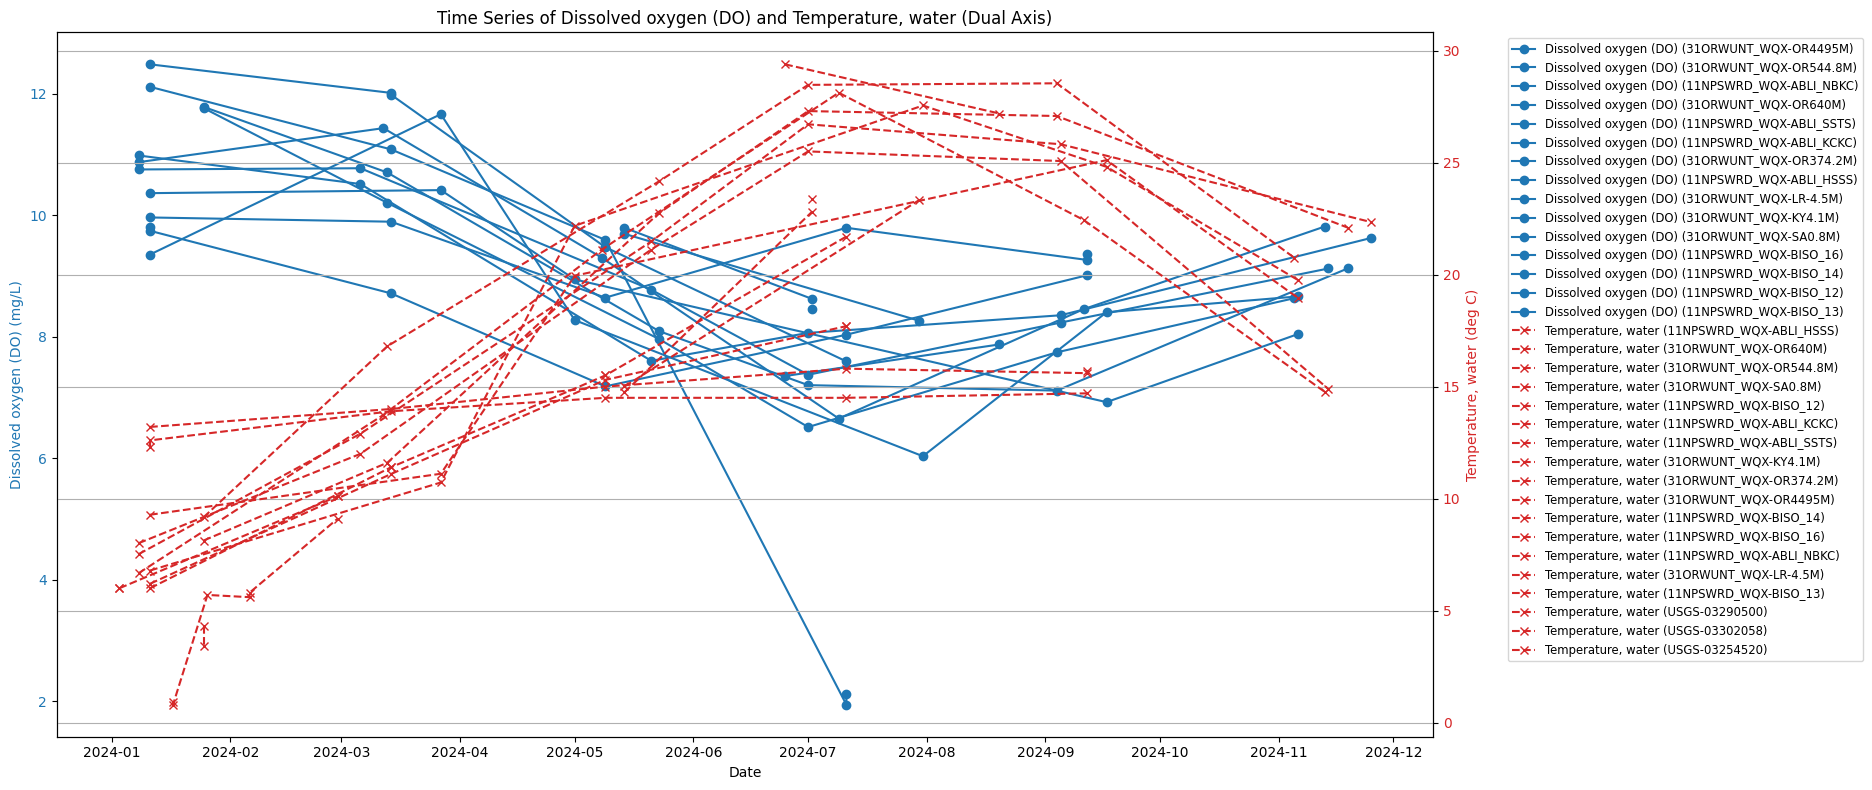

In [ ]:
plot_two_characteristics_dual_axis_time_series(narrow_df, 'Dissolved oxygen (DO)', 'Temperature, water')